This scipt provides minimum-working example to run the champion model on liquid universe of US stocks using only CRSP / Compustat / IBES from WRDS.

Need at least 64GB RAM to run. The estimated times to run are for 64GB RAM, fast 16 core CPU, and RTX 4090 GPU with 24GB memory.

## Imports
##### Import packages

In [ ]:
import os
import numpy as np
import pandas as pd
import seaborn
import matplotlib.pyplot as plt

##### Import local functions

In [2]:
# source data manager and data processing
from DataModules.ProcessData import *

# source function for creation of signals
from Signals.CreateSignals import *

# source functions for estimation of neural nets
from EstimationFunctions.NN_Functions import (
    get_anomalies_list,
    validation_logic,
    get_data,
    train_loop,
    ComputeMoments,
    AdjustMoments,
    DensityIntegrationPlots,
)

##### Other settings

In [3]:
# suppress numpy warnings - divide by zero, np.log() etc.
np.seterr(divide="ignore", invalid="ignore")

np.random.seed(123)
sPath = "./Data"

os.makedirs(os.path.join(sPath, "Features"), exist_ok=True)

##### Define variables to be used generally

In [5]:
anomalies = get_anomalies_list(sPath)
vol_vars = (
    [f"EWMAVol{i}" for i in [20, 10, 6, 4, 2, 1]]
    + [f"EWMARange{i}" for i in [20, 10, 6, 4, 2, 1]]
    + [f"EWMAVolD{i}" for i in [20, 10, 6]]
    + ["TV3M", "TV6M", "TV12M"]
)
mkt_mean_vars = ["MktAvg10_EW", "MktAvg6_EW", "MktAvg4_EW", "MktAvg1_EW", "MktAvg0.1_EW"]
taus = (
    [0.00005, 0.0001, 0.001, 0.005, 0.01, 0.02, 0.03, 0.04, 0.075]
    + [0.925, 0.96, 0.97, 0.98, 0.99, 0.995, 0.999, 0.9999, 0.99995]
    + [i / 20 for i in range(1, 20)]
)
taus.sort()

# Create Data
Takes around 3 days.
#### Raw data processing
Process raw data into Parquet files or SQL database.

In [ ]:
ProcessData(sPath, RunDB=["CRSP", "Compustat", "IBESsum", "IBESdet"])

Processing daily CRSP


#### Create signals
##### Create monthly signals

In [ ]:
Signals = CreateSignals(
    DateSequence=TimeSequence(start="1973-01-01", end="2023-12-01"),
    sPath=sPath,
    source="WRDS",
)
Signals.to_parquet(os.path.join(sPath, "Features", "WRDS_signals.gzip"), compression="gzip")

##### Create weekly signals

In [ ]:
Signals = CreateSignals(
    DateSequence=TimeSequence(start="1973-01-01", end="2023-12-31", freq="7D"),
    sPath=sPath,
    source="WRDS",
)
Signals.to_parquet(os.path.join(sPath, "Features", "WRDS_signals_W.gzip"), compression="gzip")

#### Create returns
##### Create next-month returns

In [ ]:
Ret = CreateReturns(
    DateSequenceStart=TimeSequence(start="1973-01-01", end="2023-12-01"),
    DateSequenceEnd=TimeSequence(start="1973-02-01", end="2024-01-01"),
    sPath=sPath,
    source="WRDS",
)
Ret.to_parquet(os.path.join(sPath, "Features", "WRDS_returns.gzip"), compression="gzip")

##### Create 22-business days returns

In [ ]:
Ret = CreateReturns(
    DateSequenceStart=TimeSequence(start="1973-01-01", end="2023-12-25", freq="7D"),
    DateSequenceEnd=TimeSequence(start="1973-01-31", end="2024-01-25", freq="7D"),
    sPath=sPath,
    source="WRDS",
)
Ret.to_parquet(os.path.join(sPath, "Features", "WRDS_returns_22d.gzip"), compression="gzip")

#### Create universe filters
##### Universe filters for monthly data

In [ ]:
Universe = UniverseFilter(
    DateSequence=TimeSequence(start="1973-01-01", end="2023-12-01"),
    sPath=sPath,
    source="WRDS",
)
Universe.to_parquet(os.path.join(sPath, "Features", "WRDS_universe_filter.gzip"), compression="gzip")

##### Universe filters for weekly updated data

In [ ]:
Universe = UniverseFilter(
    DateSequence=TimeSequence(start="1973-01-01", end="2023-12-31", freq="7D"),
    sPath=sPath,
    source="WRDS",
)
Universe.to_parquet(os.path.join(sPath, "Features", "WRDS_universe_filter_W.gzip"), compression="gzip")

#### Connect together returns, features, and subset the universe

##### Monthly data

In [ ]:
Signals = pd.read_parquet(os.path.join(sPath, "Features", "WRDS_signals.gzip"))
Ret = pd.read_parquet(os.path.join(sPath, "Features", "WRDS_returns.gzip"))
Universe = pd.read_parquet(os.path.join(sPath, "Features", "WRDS_universe_filter.gzip"))
dataCRSP = MLdata(Ret, Signals, Universe, source="WRDS", exc_normalize=vol_vars)
dataCRSP.to_parquet(os.path.join(sPath, "Features", "MLdata.gzip"), compression="gzip")

##### Weekly data with 22d ahead returns

In [ ]:
Signals = pd.read_parquet(os.path.join(sPath, "Features", "WRDS_signals_W.gzip"))
Ret = pd.read_parquet(os.path.join(sPath, "Features", "WRDS_returns_22d.gzip"))
Universe = pd.read_parquet(os.path.join(sPath, "Features", "WRDS_universe_filter_W.gzip"))
dataCRSP = MLdata(Ret, Signals, Universe, source="WRDS", exc_normalize=vol_vars)
dataCRSP.to_parquet(os.path.join(sPath, "Features", "MLdata_W_22d.gzip"), compression="gzip")

#### Equally-weighted market returns with different moving average filter

In [ ]:
ret = MktMeanRet(sPath, regions=["USA"])
ret.to_parquet(os.path.join(sPath, "Features", "Mkt_mean.gzip"), compression="gzip")

# Quantile Model Estimation
Run time is around 12 hours.
##### Model Parameters

In [ ]:
sample_split = validation_logic()
inputs1 = anomalies + vol_vars + mkt_mean_vars
inputs2 = [i + "_mean" for i in vol_vars]
param = {
    "tau": taus,
    "loss_f": "quantile_loss_two",
    "activation": "LeakyReLU",
    "input_size": len(inputs1),
    "input_size2": len(inputs2),
    "hidden_sizes": [128, 128, 4, 128, 128],
    "hidden_sizes2": [8],
    "output_size": len(taus),
    "initial_lr": 0.0003,
    "epochs": 100,
    "batch_size": 10000,
    "dropout_rate": 0.2,
    "stage1_l1_lambda": 0.0001,
    "stage2_l1_lambda": 0.00001,
    "stage2_l2_lambda": 0.00001,
    "num_networks": 20,
}

##### Get data

In [ ]:
# weekly data used in estimation
data = get_data(sPath, "MLdata_W_22d.gzip", vol_vars, mkt_mean_vars, regions=["USA"])

# monthly data used in prediction
data_m = get_data(sPath, "MLdata.gzip", vol_vars, mkt_mean_vars)

##### Run estimation and create predicitons

In [ ]:
pred, pred_m = train_loop(data, data_m, sample_split, param, inputs1, inputs2)

##### Save output with monthly forecast and weekly forecasts

In [ ]:
pred.to_parquet(os.path.join(sPath, "Predict", "NN_quantile_reg_M.gzip"), compression="gzip")
pred_m.to_parquet(os.path.join(sPath, "Predict", "NN_quantile_reg_M_m.gzip"), compression="gzip")

# Derive Moments
Run time is around 5 minutes.
### Density estimation - compute moments

In [ ]:
# get predictions
dt = pd.read_parquet(os.path.join(sPath, "Predict", "NN_quantile_reg_M_m.gzip"))

# compute moments without adjustment
dt = ComputeMoments(dt, taus)

# adjust the moments for imperfections in tails
dt = AdjustMoments(dt)

# clean up the results
Keep_vars = [
    "date",
    "DTID",
    "m0",  # integrated density - normalizing constant so that the probability is equal to 1
    "m1",  # non-central moments
    "m2",
    "m3",
    "m4",
    "var",  # central moments
    "std",
    "skew",
    "kurtosis",
    "var_adj",
    "skew_adj",
    "kurtosis_adj",
    "LinearFlag",
    "Error",
]
dt = dt[Keep_vars]

# constract volatility from variance
dt["std_adj"] = np.sqrt(dt["var_adj"])

# rename variables
dt.rename(
    {
        "m1": "Mean",
        "std": "Std. Dev.",
        "skew": "Skewness",
        "kurtosis": "Kurtosis",
        "std_adj": "Std. Dev. Adj",
        "skew_adj": "Skewness Adj",
        "kurtosis_adj": "Kurtosis Adj",
    },
    axis=1,
    inplace=True,
)

#### Some summary statistics

In [ ]:

res = dt.melt(
    id_vars=["date", "DTID"],
    value_vars=["Mean", "Std. Dev.", "Std. Dev. Adj", "Skewness", "Skewness Adj", "Kurtosis", "Kurtosis Adj"],
    var_name="Variable",
    value_name="Value",
)
res = res.groupby(["Variable"])["Value"].agg(["mean", "median", "std"]).reset_index()
res["mean"] = res["mean"].transform(lambda x: f"{x:0.4f}")
res["median"] = res["median"].transform(lambda x: f"{x:0.4f}")
res["std"] = res["std"].transform(lambda x: f"{x:0.4f}")
res = res.melt(id_vars=["Variable"], var_name="Stat")
res = res.sort_values(["Stat"]).set_index(["Variable", "Stat"]).unstack([1])
res = res.loc[["Mean", "Std. Dev.", "Std. Dev. Adj", "Skewness", "Skewness Adj", "Kurtosis", "Kurtosis Adj"]]
res

value                
Stat             mean  median     std
Variable                             
Mean           0.0107  0.0102  0.0116
Std. Dev.      0.1117  0.0992  0.0551
Std. Dev. Adj  0.1121  0.0995  0.0553
Skewness       0.1601  0.1524  0.1993
Skewness Adj   0.1874  0.1776  0.1866
Kurtosis       5.4826  5.2717  2.3493
Kurtosis Adj   6.9472  6.3426  8.5486

#### Histogram plots for moments

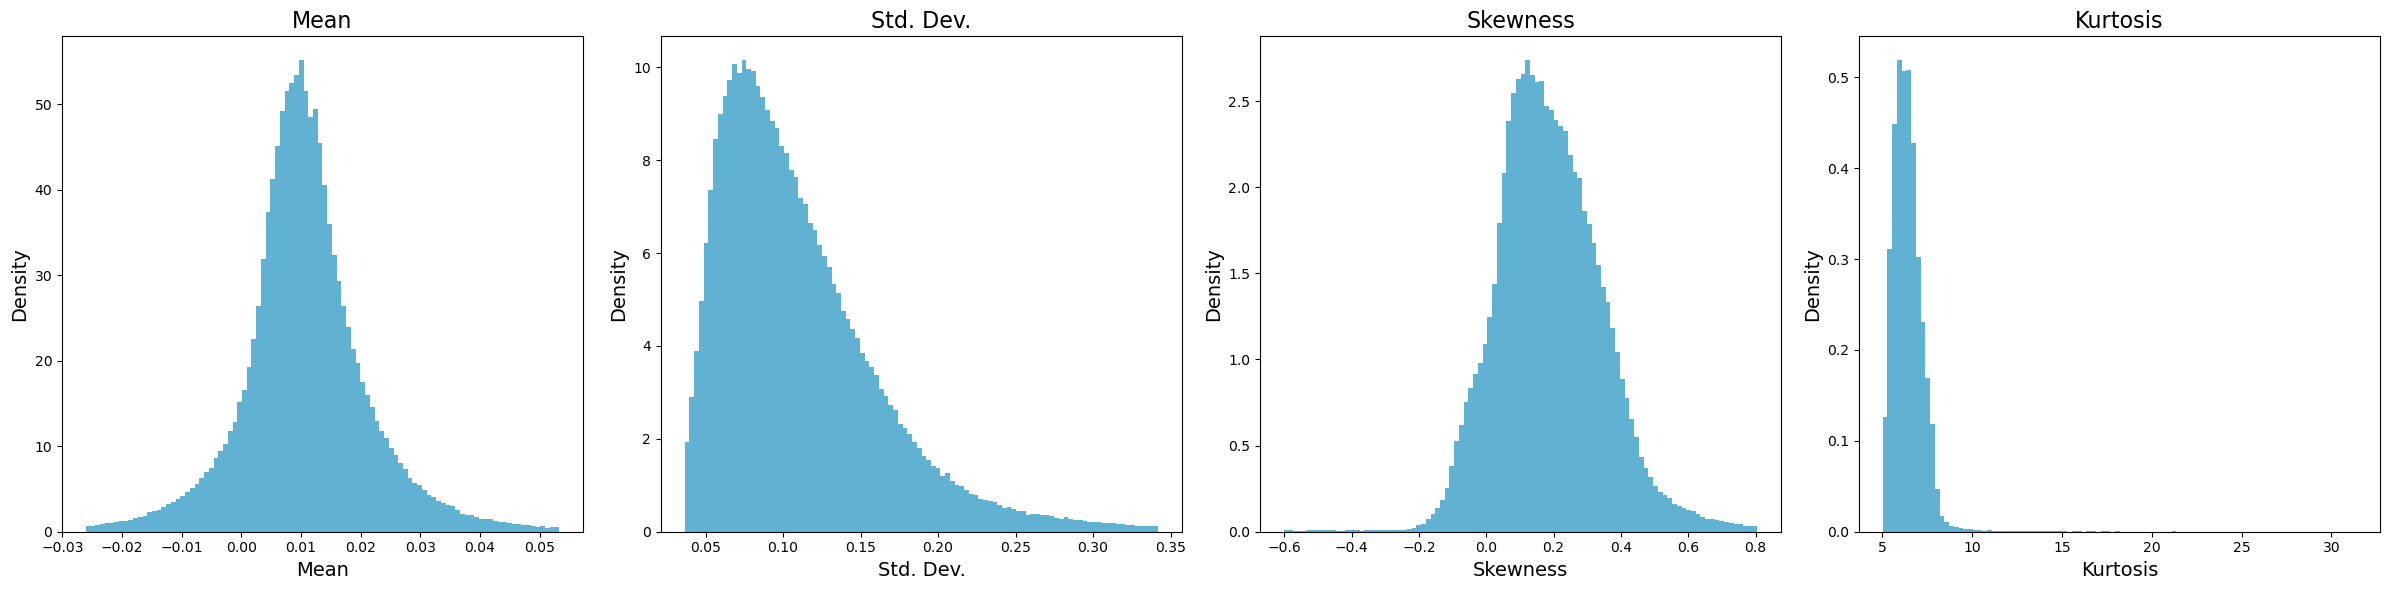

In [32]:
NameDict = {"Mean": "Mean", "Std. Dev.": "Std. Dev.", "Skewness Adj": "Skewness", "Kurtosis Adj": "Kurtosis"}
fig = plt.figure(figsize=(24, 6))
for i, Var in enumerate(["Mean", "Std. Dev.", "Skewness Adj", "Kurtosis Adj"]):
    ax = plt.subplot(1, 4, i + 1)
    dt_ = dt.loc[
        (
            (dt[Var] < dt[Var].quantile(0.995))
            & (dt[Var] > dt[Var].quantile(0.005))
        )
    ].copy()
    dt_[Var].hist(density=True, bins=100, ax=ax, label="", alpha=0.7, color="#1D91C0")
    ax.set_ylabel("Density", fontsize=14)
    ax.set_xlabel(NameDict[Var], fontsize=14)
    ax.set_title(NameDict[Var], fontsize=16)
    ax.grid(False)
fig.tight_layout()

## Plots for Derived Distribution Forecasts
### Example plot of quantiles for one ISIN

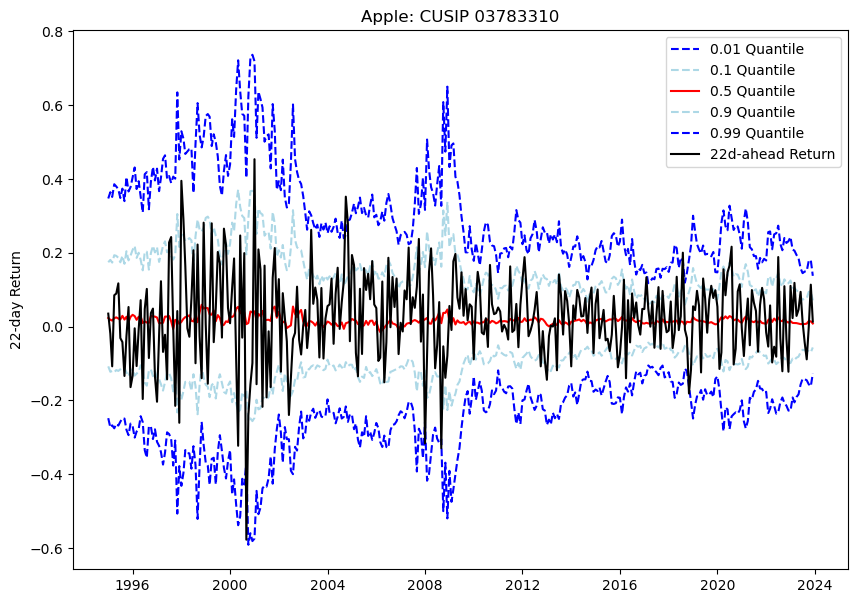

In [33]:
VarMap = {f"pred_raw_{tau}": f"{tau} Quantile" for tau in [0.01, 0.1, 0.5, 0.9, 0.99]}
VarMap["r_raw"] = "22d-ahead Return"

dt = pd.read_parquet(os.path.join(sPath, "Predict", "NN_quantile_reg_M_m.gzip"))
dt = dt.rename(VarMap, axis=1).set_index("date")
dt_ = dt.loc[dt["DTID"] == "14593"].copy()  # apple
# dt_ = dt.loc[dt["DTID"] == "14542"].copy()  # google
# dt_ = dt.loc[dt["DTID"] == "10107"].copy()  # microsoft

fig = plt.figure(figsize=(10, 7))
ax = plt.subplot(1, 1, 1)
ax.plot(dt_["0.01 Quantile"], label="0.01 Quantile", linestyle="--", color="blue")
ax.plot(dt_["0.1 Quantile"], label="0.1 Quantile", linestyle="--", color="lightblue")
ax.plot(dt_["0.5 Quantile"], label="0.5 Quantile", color="red")
ax.plot(dt_["0.9 Quantile"], label="0.9 Quantile", linestyle="--", color="lightblue")
ax.plot(dt_["0.99 Quantile"], label="0.99 Quantile", linestyle="--", color="blue")
ax.plot(dt_["22d-ahead Return"], label="22d-ahead Return", color="black")
ax.set_ylabel("22-day Return")
ax.set_xlabel("")
ax.set_title("Apple: CUSIP 03783310")
ax.legend()

### Evolution of density
#### Microsoft over 2008

date
2008-07-01    Axes(0.125,0.11;0.775x0.77)
2008-08-01    Axes(0.125,0.11;0.775x0.77)
2008-09-01    Axes(0.125,0.11;0.775x0.77)
2008-10-01    Axes(0.125,0.11;0.775x0.77)
2008-11-01    Axes(0.125,0.11;0.775x0.77)
2008-12-01    Axes(0.125,0.11;0.775x0.77)
Name: density, dtype: object

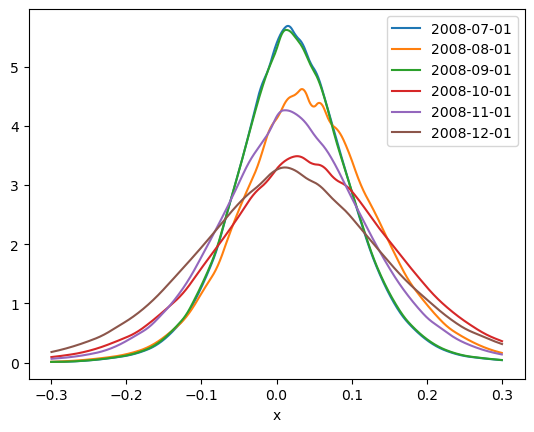

In [44]:
dt = pd.read_parquet(os.path.join(sPath, "Predict", "NN_quantile_reg_M_m.gzip"))
dt = dt.loc[(dt["date"] >= "2008-07-01") & (dt["date"] <= "2008-12-31") & (dt["DTID"] == "10107")].copy()
y = np.array(taus)
cols = [f"pred_raw_{tau}" for tau in taus]
res = []
for i, date in enumerate(dt["date"]):
    x = dt.iloc[i][cols].values.astype(float)
    res_ = DensityIntegrationPlots(x, y)
    res_["date"] = date.strftime('%Y-%m-%d')
    res += [res_]
res = pd.concat(res)
res.loc[np.abs(res["x"]) < 0.3].set_index("x").groupby("date")["density"].plot(legend=True)

#### Microsoft beginning of Oct 2008

Text(0.5, 0.98, 'Microsoft (CUSIP 59491810) October 2008')

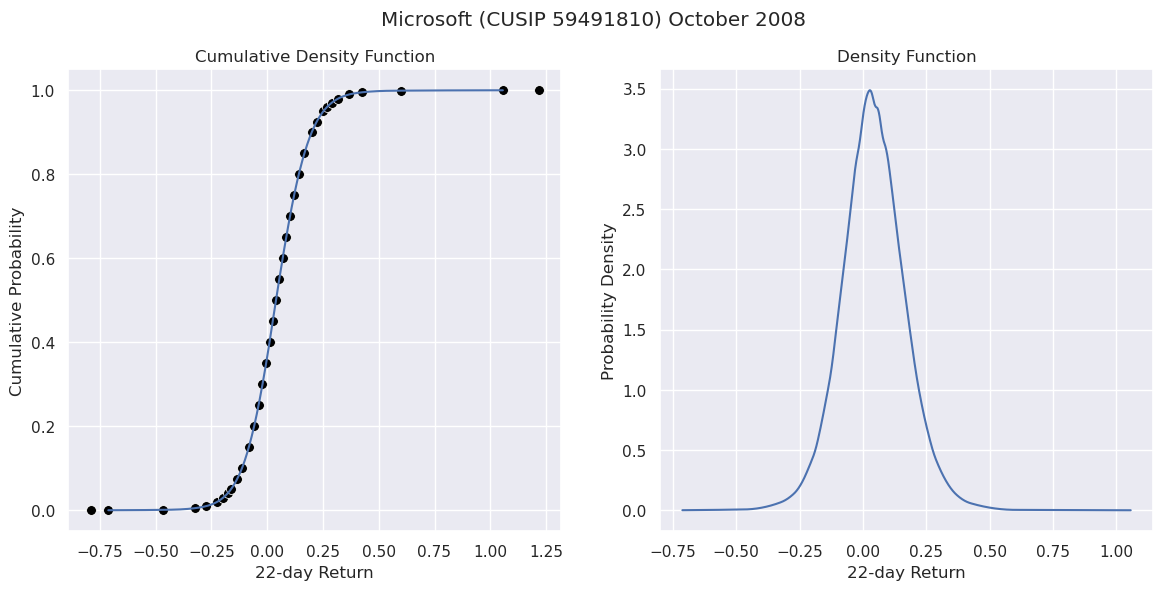

In [35]:
dt = dt.loc[(dt["date"] == "2008-10-01") & (dt["DTID"] == "10107")].copy()
y = np.array(taus)
cols = [f"pred_raw_{tau}" for tau in taus]
x = dt.iloc[0][cols].values.astype(float)
res = DensityIntegrationPlots(x, y)
fig = plt.figure(figsize=(14, 6))
seaborn.set_theme()
ax = plt.subplot(1, 2, 1)
seaborn.lineplot(data=res, ax=ax, x="x", y="cdf")
seaborn.scatterplot(ax=ax, x=x, y=y, s=50, color="black")
ax.set_xlabel("22-day Return")
ax.set_ylabel("Cumulative Probability")
ax.set_title("Cumulative Density Function")
ax = plt.subplot(1, 2, 2)
seaborn.lineplot(data=res, ax=ax, x="x", y="density")
ax.set_xlabel("22-day Return")
ax.set_ylabel("Probability Density")
ax.set_title("Density Function")
fig.suptitle("Microsoft (CUSIP 59491810) October 2008")